In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


df = pd.read_csv('/kaggle/input/notebooks/haidery05/notebooke21bf0a398/preprocessed_gasturbine_data.csv')
df.head()




,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,-1.762362,0.871052,0.401627,-0.451875,-0.377702,0.272119,0.536589,0.074502,-0.149273,-0.904182,1.426499
1,-1.801920,0.809164,0.440351,-0.458207,-0.384376,0.266417,0.568742,0.074502,-0.154783,-0.850611,1.462891
2,-1.854113,0.824636,0.483432,-0.442831,-0.375081,0.289227,0.589203,0.102033,-0.017015,-0.849020,1.582687
3,-1.875718,0.809164,0.523263,-0.445415,-0.393909,0.289227,0.586280,0.097551,-0.064774,-0.946415,1.473852
4,-1.874644,0.731804,0.505837,-0.448904,-0.392479,0.255012,0.561434,0.074502,-0.138251,-0.930328,1.433006


In [2]:
df = df.drop(['TEY','CDP'], axis=1)

These features are highly corelated which are removed to reduce redundency.

In [3]:
df.columns

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CO', 'NOX'], dtype='object')

In [4]:
df['Temp_Efficiency'] = df['TIT'] / df['AT']
df['Pressure_Ratio'] = df['AP'] / df['AT']
df['Humidity_Temp'] = df['AH'] * df['AT']
df['Gas_Efficiency'] = df['GTEP'] / df['TIT']

we have made these four features on relations observed, which are expected to improve the prediction of NOx and CO emission

In [5]:
print(df['CO'].min(), df['CO'].max())

-1.0483682153462923 18.44328583747646


In [6]:
df['CO'] = df['CO'].clip(lower=0)
df['CO_log'] = np.log1p(df['CO'])

there were some negative values which are cliped to 0 because CO emission cannot be zero.


In [7]:

df['CO_log'] = np.log1p(df['CO'])

we have applied log transformation to reduce the skewness in CO values.

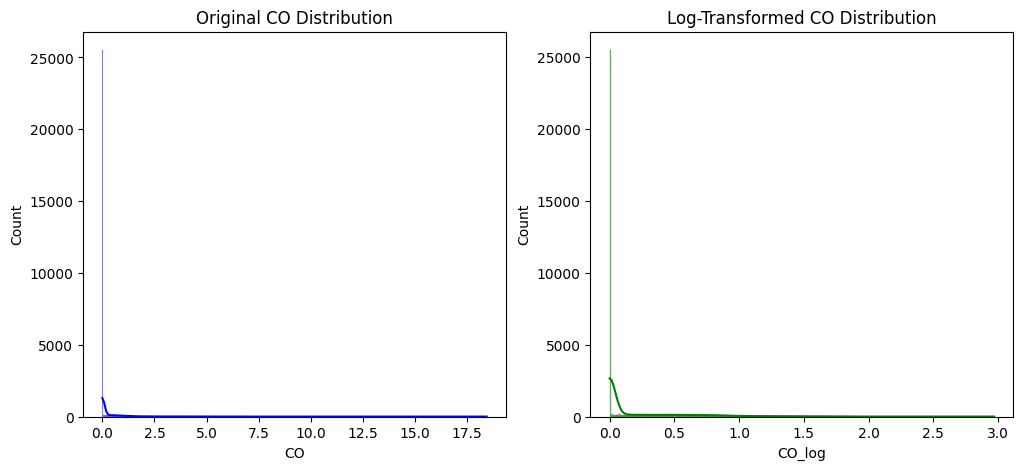

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Original CO distribution
plt.subplot(1,2,1)
sns.histplot(df['CO'], kde=True, color='blue')
plt.title("Original CO Distribution")

# Log-transformed CO distribution
plt.subplot(1,2,2)
sns.histplot(df['CO_log'], kde=True, color='green')
plt.title("Log-Transformed CO Distribution")

plt.show()

visuals before and after log transformation.

# CO prediction

In [9]:
X = df.drop(['CO','NOX','CO_log'], axis=1)
y = df['CO']

# 1.Random Forest

In [10]:
rf = RandomForestRegressor()
rf.fit(X, y)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
print("Random Forest Importance:\n", rf_imp.sort_values(ascending=False))

Random Forest Importance:
 TIT                0.475147
TAT                0.209171
AFDP               0.055392
Gas_Efficiency     0.054262
AT                 0.040353
AH                 0.035054
Humidity_Temp      0.029196
GTEP               0.029073
AP                 0.028926
Temp_Efficiency    0.021843
Pressure_Ratio     0.021582
dtype: float64


# 2. Extra Trees

In [11]:
et = ExtraTreesRegressor()
et.fit(X, y)

et_imp = pd.Series(et.feature_importances_, index=X.columns)
print("Extra Trees Importance:\n", et_imp.sort_values(ascending=False))

Extra Trees Importance:
 TIT                0.433742
TAT                0.192411
GTEP               0.092359
AFDP               0.065359
Gas_Efficiency     0.042832
AT                 0.041437
AP                 0.031696
AH                 0.028903
Humidity_Temp      0.027373
Temp_Efficiency    0.023569
Pressure_Ratio     0.020318
dtype: float64


# 3.XGBoost

In [12]:
xgb = XGBRegressor()
xgb.fit(X, y)

xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns)
print("XGBoost Importance:\n", xgb_imp.sort_values(ascending=False))

XGBoost Importance:
 TIT                0.536837
TAT                0.221108
Gas_Efficiency     0.037501
AFDP               0.033429
AT                 0.033391
GTEP               0.029901
AP                 0.028870
Humidity_Temp      0.021462
Pressure_Ratio     0.020684
AH                 0.019714
Temp_Efficiency    0.017102
dtype: float32


# 4. LightGBM

In [13]:
lgb = LGBMRegressor()
lgb.fit(X, y)

lgb_imp = pd.Series(lgb.feature_importances_, index=X.columns)
print("LightGBM Importance:\n", lgb_imp.sort_values(ascending=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2774
[LightGBM] [Info] Number of data points in the train set: 36733, number of used features: 11
[LightGBM] [Info] Start training from score 0.313251
LightGBM Importance:
 AFDP               494
TAT                392
Gas_Efficiency     316
GTEP               284
TIT                275
AP                 254
AT                 239
AH                 230
Humidity_Temp      211
Temp_Efficiency    182
Pressure_Ratio     123
dtype: int32


# 5. Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X, y)

lr_imp = pd.Series(abs(lr.coef_), index=X.columns)
print("Linear Regression Importance:\n", lr_imp.sort_values(ascending=False))

Linear Regression Importance:
 TIT                0.585275
TAT                0.338618
GTEP               0.076609
AT                 0.045999
AH                 0.025687
AFDP               0.023908
Humidity_Temp      0.016507
AP                 0.001412
Gas_Efficiency     0.001306
Temp_Efficiency    0.000013
Pressure_Ratio     0.000004
dtype: float64


In [15]:

df = df.drop(['Temp_Efficiency', 'Pressure_Ratio'], axis=1)

# remaining columns
print(df.columns)

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CO', 'NOX',
       'Humidity_Temp', 'Gas_Efficiency', 'CO_log'],
      dtype='object')


As  we have seen that both these features are shown less important in every method we have used so far so we have dropped them.

# NOx prediction

In [16]:
X = df.drop(['CO','NOX','CO_log'], axis=1)
y = df['NOX']

# 1. Random forest


In [17]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
print("Random Forest Importance:\n", rf_imp.sort_values(ascending=False))


Random Forest Importance:
 AT                0.385488
TIT               0.130903
GTEP              0.104979
Gas_Efficiency    0.102508
TAT               0.100510
AFDP              0.074769
AP                0.038758
AH                0.031896
Humidity_Temp     0.030189
dtype: float64


# 2. Extra Trees

In [18]:
et = ExtraTreesRegressor(random_state=42)
et.fit(X, y)

et_imp = pd.Series(et.feature_importances_, index=X.columns)
print("Extra Trees Importance:\n", et_imp.sort_values(ascending=False))

Extra Trees Importance:
 AT                0.336081
TIT               0.164064
TAT               0.120095
GTEP              0.110429
AFDP              0.091539
AP                0.051979
Gas_Efficiency    0.043919
Humidity_Temp     0.042187
AH                0.039707
dtype: float64


# 3. XGBoost

In [19]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X, y)

xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns)
print("XGBoost Importance:\n", xgb_imp.sort_values(ascending=False))

XGBoost Importance:
 AT                0.314063
TIT               0.163072
Gas_Efficiency    0.146154
GTEP              0.119118
TAT               0.111998
AFDP              0.051605
Humidity_Temp     0.037941
AH                0.030576
AP                0.025474
dtype: float32


# 4. LightGBM

In [20]:
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X, y)

lgbm_imp = pd.Series(lgbm.feature_importances_, index=X.columns)
print("LightGBM Importance:\n", lgbm_imp.sort_values(ascending=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2264
[LightGBM] [Info] Number of data points in the train set: 36733, number of used features: 9
[LightGBM] [Info] Start training from score 0.000000
LightGBM Importance:
 AFDP              590
AT                437
GTEP              404
TAT               384
Gas_Efficiency    331
AP                304
TIT               256
AH                216
Humidity_Temp      78
dtype: int32


# 5.  Linear Regression

In [21]:
lr = LinearRegression()
lr.fit(X, y)

lr_imp = pd.Series(lr.coef_, index=X.columns)
print("Linear Regression Coefficients:\n", lr_imp.sort_values(ascending=False))

Linear Regression Coefficients:
 TIT               0.525538
AFDP              0.074034
Gas_Efficiency   -0.002131
AP               -0.107348
Humidity_Temp    -0.157229
AH               -0.216434
TAT              -0.381845
AT               -0.720649
GTEP             -1.000608
dtype: float64


In [22]:
df = df.drop(['Humidity_Temp'], axis=1)

# remaining columns
print(df.columns)

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CO', 'NOX',
       'Gas_Efficiency', 'CO_log'],
      dtype='object')


# KMeans Features

In [23]:
X_cluster = df.drop(['CO','NOX','CO_log'], axis=1)

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_cluster)

clustring used to create new features represent operating condition.

In [24]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

df_final = pd.DataFrame(scaled, columns=df.columns)

will ensure all features are in same scale.

In [25]:
df_final.to_csv("feature_engineered_data.csv", index=False)